<a href="https://colab.research.google.com/github/Bethimen/EML_Grupo11_25-26/blob/main/Entornos_continuos/parte3_evaluaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos sobre entornos continuos

*Description:* Se compara el rendimiento de algoritmos Deep Q-Learning y SARSA semi gradiente, frente a varias experimentos.

In [ ]:
# Importación de librerías
import os
import gc
import gymnasium as gym
import flappy_bird_gymnasium
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
from collections import deque
import tqdm


# Configuración del dispositivo (CPU o GPU)
device = torch.device("cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


# Configuración de la semilla para reproducibilidad
SEED = 2024


# Fijar la semilla en NumPy
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Fijar la semilla en Python (hash)
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

# Fijar la semilla en PyTorch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def moving_average(x, w=500):
    if len(x) < w:
        return np.array(x)
    return np.convolve(x, np.ones(w)/w, mode="valid")

print(f"Semilla global establecida: {SEED}")

Usando dispositivo: cpu
Semilla global establecida: 2024


In [ ]:
N_EPISODES = 1500
N_EVAL_EPISODES = 500
N_SMOOTH = 100

# 1. Introducción

Flappy Bird es un entorno de Gymnasium donde un agente
debe controlar a un pájaro para navegar a través de huecos
entre tuberías. Es un problema de aprendizaje por refuerzo
episódico con espacios de estados cotinuos (posición horizon-
tal/vertical de las tuberías, velocidad, rotación) y un espacio
de acciones discreto binario (saltar o no saltar). Es una tarea
de control interesante por su baja tolerancia al error, un error
puede significar la terminación y pérdida del juego.
La importancia de este problema se basa en su baja tolerancia
al error, permite estudiar el efecto de estrategias on-policy que
pueden aprender politicas más conservadoras y estrategias off-
policy que podrían arriesgar más en busca de maximizar la
recompensa, este problema podría plantear una analogía con
el problema ’Cliff Walking’ descrito por Sutton & Barto.
Se pretende implementar y calibrar los algoritmos SARSA
Semi gradiente y Deep Q-learning, utilizando para el primero
Tile coding para aproximar las funciones dado el espacio de
estados continuos. Además se pretende analizar el impacto
de diferentes arquitecturas en Deep Q-learning, en soluciones
basadas en n-pasos y en agrupación de estados o información
de varios estados por ejemplo los 3 últimos estados. Analiza-
remos la velocidad de convergencia, la estabilidad del apren-
dizaje, estimaremos el riesgo asumido por cada algoritmo y
trataremos de visualizar la política aprendida con mapas de
calor enfatizando 2 características del estado.
El documento se organiza en una sección de desarrollo que
define el problema, los enfoques existentes y los antecedentes,
explicaremos los métodos utilizados para aboradar el proble-
ma y justificaremos en que se diferencia el trabajo actual con
respocto a los anteriores.

# 2. Entorno elegido

Una vez definidas las reglas, presentaremos la representación
formal utilizada para el problema de Flappy Bird basado en
la Opción 2 de observaciones.

**Espacio de estados**

Cada observación del entorno nos dará un estado que define la
situación cinemática del agente y los obstáculos inmediatos.
Definimos nuestro espacio de estados de la siguiente mane-
ra,cada estado es un vector de 12 variables continuas:
- Posiciones de tuberías (9 variables): Incluye la posición
horizontal y las posiciones verticales (superior e inferior)
de la tubería anterior, la siguiente y la subsiguiente.
- Estado del jugador (3 variables): Describe la posición ver-
tical, la velocidad vertical y la rotación actual del pájaro.


En Gymnasium, este espacio está definido por un objeto Box
de 12 dimensiones: Box(low=-inf, high=inf, shape=(12,), dty-
pe=np.float32). Aunque el espacio es infinito, la dinámica del
juego restringe los estados accesibles. Por ejemplo, la rota-
ción y la velocidad están limitadas por la física del entorno,el
pájaro no puede visitar posiciones fuera de los límites de la
pantalla sin terminar el episodio, no puede tener una rota-
ción que lo coloque mirando hacia el inicio, etc. Las variables
que modelizan el estado son números en coma flotante por lo
que potencialmente podríamos tener $12^{2^{b}}$
estados diferentes,
siendo $b$ el número de bits utilizados para representar esos
números(en este caso 32), es un conjunto que no podría ser
almacenado por un ordenador, impidiendo el uso de métodos
tabulares.

**Espacio de acciones**

El espacio de acciones discreto está definido en el rango 0,1
tal que:
- 0: No hacer nada. El pájaro cae por efecto de la gravedad.
- 1: Saltar (flap). Se aplica un impulso ascendente al agen-
te.

**Recompensas**

Para cada acción tomada por el agente, definimos las recom-
pensas de la siguiente manera:
- +0.1 por cada frame que el agente permanezca con vida.
- +1.0 por cada tubería superada con éxito.+1.0 por cada
tubería superada con éxito.
- -1.0 si el agente colisiona (estado terminal).
- -0.5 si el agente toca el límite superior de la pantalla.
-
Siguiendo la hipótesis de la recompensa, estos valores buscan
formalizar el objetivo de supervivencia a largo plazo. La pe-
nalización por tocar el techo incentiva al agente a mantenerse
en zonas seguras, evitando trayectorias extremas.


# 3. Experimentos

## 3.1. Establecimiento de la Línea Base (Baselines)

En este apartado se construye un baseline con un agente aleatorio
- **Baseline Aleatorio**: agente que actúa al azar para demostrar que el problema no es trivial.


In [ ]:
from src.agents.randomAgent import RandomAgent
import matplotlib.pyplot as plt
import numpy as np

def env_factory_baseline(seed: int = SEED) -> gym.Env:
    # Usamos LiDAR para mantener consistencia con el problema principal.
    env = gym.make('FlappyBird-v0', use_lidar=True)
    env.reset(seed=seed)
    return env

def evaluate_random_agent(env, episodes: int = 1000, max_steps: int = 2000):
    rewards, steps, scores = [], [], []
    agent = RandomAgent(env, seed=SEED)

    for _ in range(episodes):
        obs, _ = env.reset(seed=SEED)
        total_reward = 0.0
        step_count = 0
        done = False
        score = 0.0

        while step_count < max_steps and not done:
            action = agent.get_action(obs, evaluate=True)
            next_obs, reward, terminated, truncated, info = env.step(action)
            obs = next_obs
            total_reward += reward
            step_count += 1
            done = bool(terminated or truncated)
            if isinstance(info, dict) and "score" in info:
                score = info["score"]

        rewards.append(float(total_reward))
        steps.append(step_count)
        scores.append(float(score))

    return rewards, steps, scores

print("Evaluando agente aleatorio (sin entrenamiento)...")
env_baseline = env_factory_baseline(SEED)
random_rewards, random_steps, random_scores = evaluate_random_agent(
    env_baseline,
    episodes=N_EVAL_EPISODES,
    max_steps=2000,
)

results_random = {
    "name": "Random Agent",
    "rewards": random_rewards,
    "steps": random_steps,
    "score": random_scores,
}

print("Evaluación completada para Random Agent")

Evaluando agente aleatorio (sin entrenamiento)...


c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\gymnasium\utils\passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Evaluación completada para Random Agent


En la siguiente celda de código generamos las gráficas para analizar el entrenamiento

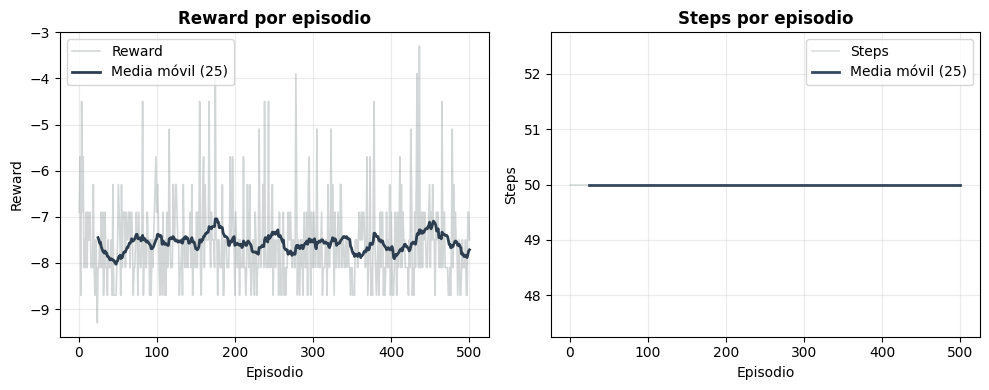


--- Baseline Random Agent ---
Episodios evaluados: 500
Reward -> media=-7.56, std=0.93, mediana=-7.50
Steps  -> media=50.00, std=0.00, mediana=50.00
Score  -> media=0.00, std=0.00, mediana=0.00


In [ ]:
# ============ GRÁFICAS: Baseline Random Agent ============
r = np.asarray(results_random["rewards"], dtype=float)
s = np.asarray(results_random["steps"], dtype=float)
sc = np.asarray(results_random["score"], dtype=float)

n = len(r)
window = max(5, min(25, n // 5)) if n > 10 else max(1, n)

def smooth(x, w):
    if len(x) < w or w <= 1:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

x_ep = np.arange(1, n + 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 1) Reward por episodio
ax[0].plot(x_ep, r, color="#7f8c8d", alpha=0.35, linewidth=1.2, label="Reward")
r_sm = smooth(r, window)
ax[0].plot(np.arange(window, window + len(r_sm)), r_sm, color="#2c3e50", linewidth=2.0, label=f"Media móvil ({window})")
ax[0].set_title("Reward por episodio", fontsize=12, fontweight="bold")
ax[0].set_xlabel("Episodio")
ax[0].set_ylabel("Reward")
ax[0].grid(alpha=0.25)
ax[0].legend()

# 2) Steps por episodio
ax[1].plot(x_ep, s, color="#95a5a6", alpha=0.35, linewidth=1.2, label="Steps")
s_sm = smooth(s, window)
ax[1].plot(np.arange(window, window + len(s_sm)), s_sm, color="#34495e", linewidth=2.0, label=f"Media móvil ({window})")
ax[1].set_title("Steps por episodio", fontsize=12, fontweight="bold")
ax[1].set_xlabel("Episodio")
ax[1].set_ylabel("Steps")
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.tight_layout()
plt.show()

# Resumen numérico final
print("\n--- Baseline Random Agent ---")
print(f"Episodios evaluados: {n}")
print(f"Reward -> media={np.mean(r):.2f}, std={np.std(r):.2f}, mediana={np.median(r):.2f}")
print(f"Steps  -> media={np.mean(s):.2f}, std={np.std(s):.2f}, mediana={np.median(s):.2f}")
print(f"Score  -> media={np.mean(sc):.2f}, std={np.std(sc):.2f}, mediana={np.median(sc):.2f}")

Podemos ver que el baseline aleatorio no consigue pasar de 50 pasos siendo, esto representa que no consigue ni siquiera superar la primera tubería. Por otro lado las recompensas oscilan entorno a -8 y -7.

## 3.2. Calibración Individual de Algoritmos (Ajuste)

### 3.2.1 Ajuste SARSA + Tile Coding

Se calibra SARSA+Tile Coding con barridos  de resolución (`bins`) para validar generalización en estados continuos.

### 3.2.2 Ajuste DQN

Se calibra DQN con barrido de `learning_rate` y `buffer_capacity`, para estabilizar el aprendizaje off-policy con redes neuronales.

In [ ]:
from src.agents.SARSA_semi_grad import SARSASemiGradAgent
from src.agents.deep_q_learning import DQNAgent

# =========================
# Configuración y utilidades comunes
# =========================

def make_option2_env(seed: int = SEED):
    env = gym.make('FlappyBird-v0', use_lidar=False)
    env.reset(seed=seed)
    return env


class SimpleTileCoder:
    """
    Tile Coding inspirado en el notebook del profesor:
    - construye varias rejillas (tilings) desplazadas
    - discretiza con np.digitize en cada tiling
    - codifica en un vector disperso hash-based para evitar explosión dimensional
    """

    def __init__(self, low, high, n_tilings=8, bins=8, iht_size=4096, seed=SEED):
        self.n_tilings = int(n_tilings)
        self.iht_size = int(iht_size)
        self.seed = seed

        low = np.asarray(low, dtype=np.float32).reshape(-1)
        high = np.asarray(high, dtype=np.float32).reshape(-1)

        low = np.where(np.isfinite(low), low, -1.0)
        high = np.where(np.isfinite(high), high, 1.0)
        span = high - low
        span = np.where(np.abs(span) < 1e-8, 1.0, span)

        self.low = low
        self.high = low + span

        if np.isscalar(bins):
            self.bins = np.full(self.low.shape[0], int(bins), dtype=np.int32)
        else:
            self.bins = np.asarray(bins, dtype=np.int32)
            if self.bins.shape[0] != self.low.shape[0]:
                raise ValueError("bins debe tener la misma dimensión que la observación.")

        self.tilings = self._create_tilings(self.bins, self.high, self.low, self.n_tilings)

    def _create_tilings(self, bins, high, low, n):
        rng = random.Random(self.seed)
        displacement_vector = np.arange(1, 2 * len(bins), 2)

        tilings = []
        for i in range(1, n + 1):
            low_i = low - rng.random() * 0.2 * low
            high_i = high + rng.random() * 0.2 * high

            displacements = displacement_vector * i % n
            segment_sizes = (high_i - low_i) / bins
            displacements = displacements * (segment_sizes / n)

            low_i += displacements
            high_i += displacements

            buckets_i = [np.linspace(j, k, l - 1) for j, k, l in zip(low_i, high_i, bins)]
            tilings.append(buckets_i)

        return tilings

    def _digitize_obs(self, obs):
        obs = np.asarray(obs, dtype=np.float32).reshape(-1)
        obs = np.clip(obs, self.low, self.high)
        indices = []
        for t in self.tilings:
            tiling_indices = tuple(np.digitize(i, b) for i, b in zip(obs, t))
            indices.append(tiling_indices)
        return indices

    def encode(self, obs):
        x = np.zeros(self.iht_size, dtype=np.float32)
        for t_idx, tiling_idx in enumerate(self._digitize_obs(obs)):
            idx = hash((t_idx, *tiling_idx)) % self.iht_size
            x[idx] = 1.0
        x /= self.n_tilings
        return x


def evaluate_greedy(agent, env, episodes=100, max_steps=2000, seed=SEED):
    rewards = []
    old_eps = getattr(agent, "epsilon", None)
    if old_eps is not None:
        agent.epsilon = 0.0

    for ep in range(episodes):
        obs, _ = env.reset(seed=seed + 10_000 + ep)
        if isinstance(obs, np.ndarray):
            obs = np.asarray(obs, dtype=np.float32).reshape(-1)

        total_reward = 0.0
        done = False
        step_count = 0

        while step_count < max_steps and not done:
            action = agent.get_action(obs, evaluate=True)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            obs = np.asarray(next_obs, dtype=np.float32).reshape(-1) if isinstance(next_obs, np.ndarray) else next_obs
            total_reward += float(reward)
            step_count += 1
            done = bool(terminated or truncated)

        rewards.append(total_reward)

    if old_eps is not None:
        agent.epsilon = old_eps

    return np.array(rewards)


# Hiperparámetros para barridos
n_tilings = 8
pow2 = [2 ** (-k) for k in [1, 2, 3, 4, 5]]
alpha_grid = [p / n_tilings for p in pow2]
bins_grid = [6, 8, 10, 12]
lr_grid = [1e-3, 5e-4, 1e-4, 5e-5]
buffer_grid = [10000, 30000, 50000]


Configuración fija de entorno y barrido sobre:
- resolución del Tile Coding (`bins`) {6, 8, 10, 12}

In [ ]:
# =========================
# 3.3b - Guardar trazas completas por configuración (Tile Coding)
# =========================


sarsa_traces = {}

alpha_fixed = 0.01
sweep_episodes_sarsa = N_EPISODES

for bins in bins_grid:
    env_sarsa_tmp = make_option2_env(SEED)
    tc = SimpleTileCoder(
        low=env_sarsa_tmp.observation_space.low,
        high=env_sarsa_tmp.observation_space.high,
        n_tilings=n_tilings,
        bins=bins,
        iht_size=4096,
        seed=SEED,
    )

    sarsa_agent_tmp = SARSASemiGradAgent(
        env_sarsa_tmp,
        alpha=alpha_fixed,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        n_steps=1,
        feature_encoder=tc.encode,
        seed=SEED,
    )

    r_sarsa_tmp, st_sarsa_tmp, sc_sarsa_tmp = sarsa_agent_tmp.train(
        episodes=sweep_episodes_sarsa, max_steps=2000
    )

    sarsa_traces[bins] = {
        "rewards": np.asarray(r_sarsa_tmp, dtype=float),
        "steps": np.asarray(st_sarsa_tmp, dtype=float),
        "scores": np.asarray(sc_sarsa_tmp, dtype=float),
    }

print("Trazas SARSA por bins guardadas:", list(sarsa_traces.keys()))

SARSA semi-grad n=1: 100%|██████████| 1500/1500 [01:53<00:00, 13.16ep/s]

Trazas SARSA por bins guardadas: [6, 8, 10, 12]


En la siguiente celda mostramos las gráficas de ejecución de las distintas configuraciones de bins en el tile coding

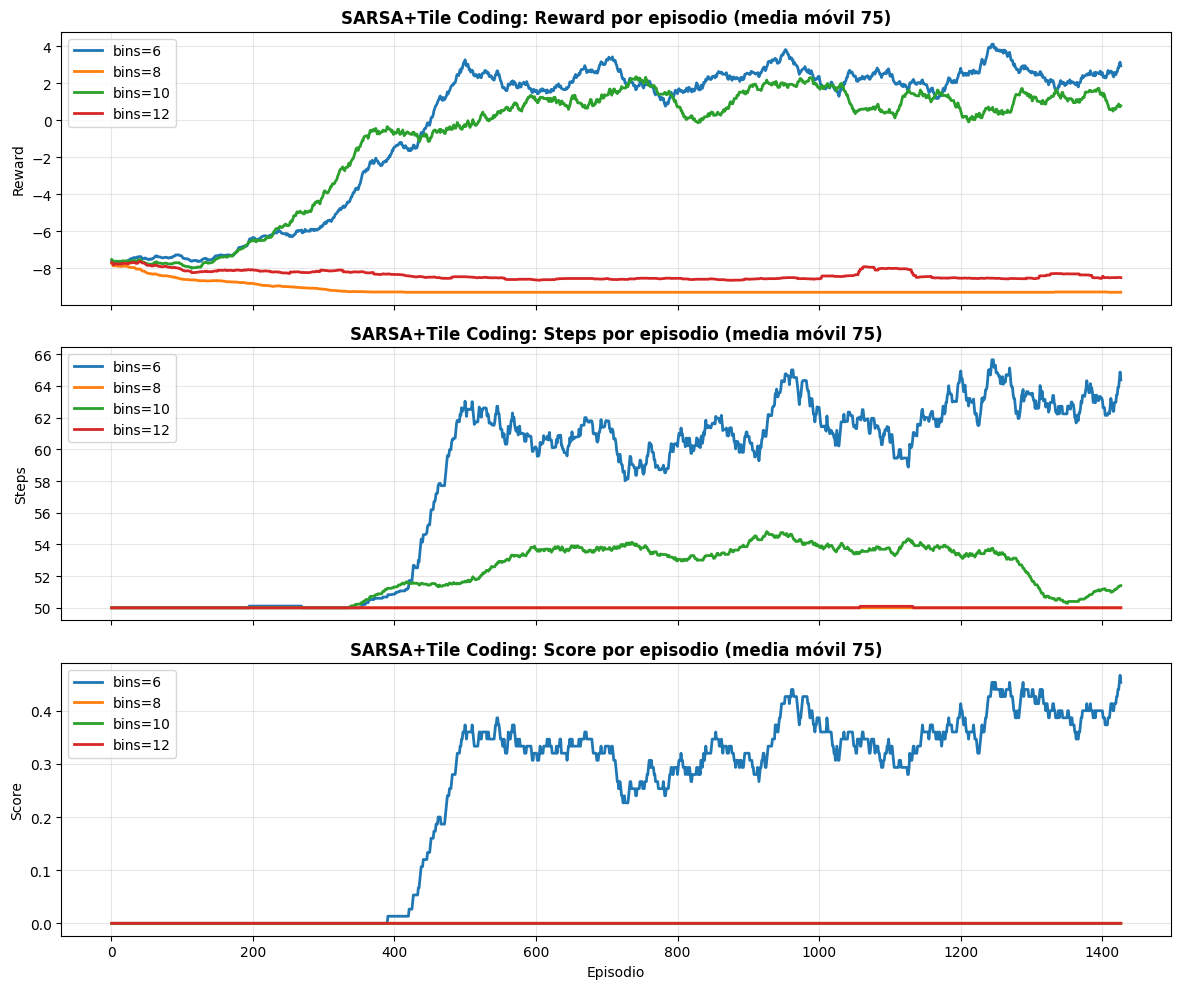

In [ ]:
# =========================
# 3.3c - Gráficas de entrenamiento por episodio para cada configuración de Tile Coding
# =========================

def ma(x, w):
    x = np.asarray(x, dtype=float)
    if len(x) < w or w <= 1:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

w = min(N_SMOOTH, max(20, N_EPISODES // 20))
colors = {6: "#1f77b4", 8: "#ff7f0e", 10: "#2ca02c", 12: "#d62728"}

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for bins in sorted(sarsa_traces.keys()):
    r = sarsa_traces[bins]["rewards"]
    st = sarsa_traces[bins]["steps"]
    sc = sarsa_traces[bins]["scores"]

    r_sm = ma(r, w)
    st_sm = ma(st, w)
    sc_sm = ma(sc, w)

    x_r = np.arange(1, len(r_sm) + 1)
    x_st = np.arange(1, len(st_sm) + 1)
    x_sc = np.arange(1, len(sc_sm) + 1)

    c = colors.get(bins, None)

    ax[0].plot(x_r, r_sm, linewidth=2.0, color=c, label=f"bins={bins}")
    ax[1].plot(x_st, st_sm, linewidth=2.0, color=c, label=f"bins={bins}")
    ax[2].plot(x_sc, sc_sm, linewidth=2.0, color=c, label=f"bins={bins}")

ax[0].set_title(f"SARSA+Tile Coding: Reward por episodio (media móvil {w})", fontweight="bold")
ax[1].set_title(f"SARSA+Tile Coding: Steps por episodio (media móvil {w})", fontweight="bold")
ax[2].set_title(f"SARSA+Tile Coding: Score por episodio (media móvil {w})", fontweight="bold")

ax[0].set_ylabel("Reward")
ax[1].set_ylabel("Steps")
ax[2].set_ylabel("Score")
ax[2].set_xlabel("Episodio")

for i in range(3):
    ax[i].grid(alpha=0.3)
    ax[i].legend()

plt.tight_layout()
plt.show()

Podemos ver que los bins pequeños 6 y 8 permiten una convergencia en menos tiempo por la mayor generaliación, mientras que los 10 y 12 bins ni si quiera consiguen converger a una recompensa positiva

Configuración fija de entorno y barrido sobre:
- `learning_rate`
- `buffer_capacity`

Selección por rendimiento medio en los últimos episodios del barrido.

In [ ]:
# 3.4 - Ejecución: barrido de learning_rate y buffer (DQN)
sweep_episodes_dqn = N_EPISODES
dqn_sweep_results = []

for lr in lr_grid:
    for buffer_capacity in buffer_grid:
        env_dqn_tmp = make_option2_env(SEED)

        dqn_tmp = DQNAgent(
            env_dqn_tmp,
            hidden_dim=64,
            num_layers=3,
            learning_rate=lr,
            gamma=0.99,
            epsilon_start=1.0,
            epsilon_min=0.05,
            epsilon_decay=0.995,
            buffer_capacity=buffer_capacity,
            batch_size=32,
            n_steps=1,
            learning_starts=1000,
            train_freq=10,
            target_update_freq=500,
            tau=1.0,
            double_dqn=True,
            seed=SEED,
            device=device,
        )

        r_dqn_tmp, st_dqn_tmp, _ = dqn_tmp.train(episodes=sweep_episodes_dqn, max_steps=2000)
        r_dqn_tmp = np.asarray(r_dqn_tmp, dtype=float)
        st_dqn_tmp = np.asarray(st_dqn_tmp, dtype=float)

        dqn_sweep_results.append({
            "learning_rate": lr,
            "buffer_capacity": buffer_capacity,
            "reward_last50": float(np.mean(r_dqn_tmp[-50:])),
            "steps_last50": float(np.mean(st_dqn_tmp[-50:])),
        })

best_dqn_cfg = max(dqn_sweep_results, key=lambda d: d["reward_last50"])

print("\n=== Ajuste DQN (learning_rate + buffer_capacity) ===")
for row in sorted(dqn_sweep_results, key=lambda d: (d["learning_rate"], d["buffer_capacity"])):
    print(
        f"lr={row['learning_rate']:.0e} | buffer={row['buffer_capacity']:5d} | "
        f"reward_last50={row['reward_last50']:.3f} | steps_last50={row['steps_last50']:.1f}"
    )
print(
    f"Mejor config DQN -> lr={best_dqn_cfg['learning_rate']:.0e}, "
    f"buffer={best_dqn_cfg['buffer_capacity']}, reward_last50={best_dqn_cfg['reward_last50']:.3f}"
)

DQN n=1: 100%|██████████| 1500/1500 [00:31<00:00, 47.59ep/s]


=== Ajuste DQN (learning_rate + buffer_capacity) ===
lr=5e-05 | buffer=10000 | reward_last50=4.530 | steps_last50=55.3
lr=5e-05 | buffer=30000 | reward_last50=4.102 | steps_last50=51.7
lr=5e-05 | buffer=50000 | reward_last50=4.016 | steps_last50=50.8
lr=1e-04 | buffer=10000 | reward_last50=5.352 | steps_last50=60.7
lr=1e-04 | buffer=30000 | reward_last50=4.106 | steps_last50=51.5
lr=1e-04 | buffer=50000 | reward_last50=4.186 | steps_last50=52.3
lr=5e-04 | buffer=10000 | reward_last50=5.490 | steps_last50=62.5
lr=5e-04 | buffer=30000 | reward_last50=5.986 | steps_last50=66.0
lr=5e-04 | buffer=50000 | reward_last50=4.218 | steps_last50=53.1
lr=1e-03 | buffer=10000 | reward_last50=6.332 | steps_last50=69.1
lr=1e-03 | buffer=30000 | reward_last50=6.740 | steps_last50=72.1
lr=1e-03 | buffer=50000 | reward_last50=4.258 | steps_last50=53.2
Mejor config DQN -> lr=1e-03, buffer=30000, reward_last50=6.740


### 3.2.3 Comparación principal SARSA vs DQN

Con las mejores configuraciones encontradas para cada algoritmo, se comparan métricas:
- **online** (curvas de aprendizaje)
- **offline** (evaluación greedy)

In [ ]:
# Comparación principal - ejecución con mejores configuraciones
compare_episodes = N_EPISODES

env_sarsa = make_option2_env(SEED)
env_dqn = make_option2_env(SEED)

tc_sarsa = SimpleTileCoder(
    env_sarsa.observation_space.low,
    env_sarsa.observation_space.high,
    n_tilings=n_tilings,
    bins=6,
    iht_size=4096,
    seed=SEED,
)

sarsa_agent = SARSASemiGradAgent(
    env_sarsa,
    alpha=0.01,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    n_steps=1,
    feature_encoder=tc_sarsa.encode,
    seed=SEED,
)

dqn_agent = DQNAgent(
    env_dqn,
    hidden_dim=128,
    num_layers=3,
    learning_rate=best_dqn_cfg["learning_rate"],
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    buffer_capacity=best_dqn_cfg["buffer_capacity"],
    batch_size=32,
    n_steps=1,
    learning_starts=1000,
    train_freq=10,
    target_update_freq=500,
    tau=1.0,
    double_dqn=True,
    seed=SEED,
    device=device,
)

r_sarsa, st_sarsa, sc_sarsa = sarsa_agent.train(episodes=compare_episodes, max_steps=2000)
r_dqn, st_dqn, sc_dqn = dqn_agent.train(episodes=compare_episodes, max_steps=2000)

r_sarsa = np.asarray(r_sarsa, dtype=float)
st_sarsa = np.asarray(st_sarsa, dtype=float)
sc_sarsa = np.asarray(sc_sarsa, dtype=float)
r_dqn = np.asarray(r_dqn, dtype=float)
st_dqn = np.asarray(st_dqn, dtype=float)
sc_dqn = np.asarray(sc_dqn, dtype=float)

offline_sarsa = evaluate_greedy(sarsa_agent, env_sarsa, episodes=N_EVAL_EPISODES, max_steps=2000, seed=SEED)
offline_dqn = evaluate_greedy(dqn_agent, env_dqn, episodes=N_EVAL_EPISODES, max_steps=2000, seed=SEED)

# Guardado de mejores modelos para reutilizar en 3.6, 3.7 y 3.8
MODEL_DIR = os.path.join("Entornos_continuos", "artifacts")
os.makedirs(MODEL_DIR, exist_ok=True)

SARSA_CKPT_PATH = os.path.join(MODEL_DIR, "best_sarsa_tc.pt")
DQN_CKPT_PATH = os.path.join(MODEL_DIR, "best_dqn.pt")

sarsa_ckpt = {
    "weights": sarsa_agent.weights.copy(),
    "alpha": 0.01,
    "bins": 6,
    "n_tilings": n_tilings,
    "iht_size": tc_sarsa.iht_size,
    "low": tc_sarsa.low.copy(),
    "high": tc_sarsa.high.copy(),
    "gamma": 0.99,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.995,
    "seed": SEED,
}

dqn_ckpt = {
    "q_net_state_dict": dqn_agent.q_net.state_dict(),
    "hidden_dim": 64,
    "num_layers": 3,
    "learning_rate": best_dqn_cfg["learning_rate"],
    "buffer_capacity": best_dqn_cfg["buffer_capacity"],
    "gamma": 0.99,
    "epsilon_min": 0.05,
    "epsilon_decay": 0.995,
    "seed": SEED,
}

torch.save(sarsa_ckpt, SARSA_CKPT_PATH)
torch.save(dqn_ckpt, DQN_CKPT_PATH)
print(f"Checkpoint SARSA guardado en: {SARSA_CKPT_PATH}")
print(f"Checkpoint DQN guardado en: {DQN_CKPT_PATH}")


def load_best_agents_for_analysis():
    """Carga agentes guardados para análisis 3.6/3.7/3.8."""
    env_sarsa_eval = make_option2_env(SEED)
    env_dqn_eval = make_option2_env(SEED)

    if not (os.path.exists(SARSA_CKPT_PATH) and os.path.exists(DQN_CKPT_PATH)):
        return sarsa_agent, dqn_agent, env_sarsa_eval, env_dqn_eval

    s_ckpt = torch.load(SARSA_CKPT_PATH, map_location="cpu")
    d_ckpt = torch.load(DQN_CKPT_PATH, map_location="cpu")

    tc_eval = SimpleTileCoder(
        low=s_ckpt["low"],
        high=s_ckpt["high"],
        n_tilings=int(s_ckpt["n_tilings"]),
        bins=int(s_ckpt["bins"]),
        iht_size=int(s_ckpt["iht_size"]),
        seed=int(s_ckpt.get("seed", SEED)),
    )

    sarsa_eval = SARSASemiGradAgent(
        env_sarsa_eval,
        alpha=float(s_ckpt["alpha"]),
        gamma=float(s_ckpt.get("gamma", 0.99)),
        epsilon_start=0.0,
        epsilon_min=float(s_ckpt.get("epsilon_min", 0.05)),
        epsilon_decay=float(s_ckpt.get("epsilon_decay", 0.995)),
        n_steps=1,
        feature_encoder=tc_eval.encode,
        seed=int(s_ckpt.get("seed", SEED)),
    )
    sarsa_eval.weights = np.asarray(s_ckpt["weights"], dtype=np.float32)

    dqn_eval = DQNAgent(
        env_dqn_eval,
        hidden_dim=int(d_ckpt.get("hidden_dim", 64)),
        num_layers=int(d_ckpt.get("num_layers", 3)),
        learning_rate=float(d_ckpt.get("learning_rate", best_dqn_cfg["learning_rate"])),
        gamma=float(d_ckpt.get("gamma", 0.99)),
        epsilon_start=0.0,
        epsilon_min=float(d_ckpt.get("epsilon_min", 0.05)),
        epsilon_decay=float(d_ckpt.get("epsilon_decay", 0.995)),
        buffer_capacity=int(d_ckpt.get("buffer_capacity", best_dqn_cfg["buffer_capacity"])),
        batch_size=32,
        n_steps=1,
        learning_starts=1000,
        train_freq=10,
        target_update_freq=500,
        tau=1.0,
        double_dqn=True,
        seed=int(d_ckpt.get("seed", SEED)),
        device=device,
    )
    dqn_eval.q_net.load_state_dict(d_ckpt["q_net_state_dict"])
    dqn_eval.q_net.eval()

    return sarsa_eval, dqn_eval, env_sarsa_eval, env_dqn_eval

DQN n=1: 100%|██████████| 1500/1500 [00:34<00:00, 43.03ep/s]


Checkpoint SARSA guardado en: Entornos_continuos\artifacts\best_sarsa_tc.pt
Checkpoint DQN guardado en: Entornos_continuos\artifacts\best_dqn.pt


En la siguiente celda mostramos las gráficas del entrenamiento y evaluación greedy realizadas de SARSA y DQN

C:\Users\AntonioLuisTorres\AppData\Local\Temp\ipykernel_6800\47862360.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1, 1].boxplot([offline_sarsa, offline_dqn], labels=["SARSA+TC", "DQN"], patch_artist=True)


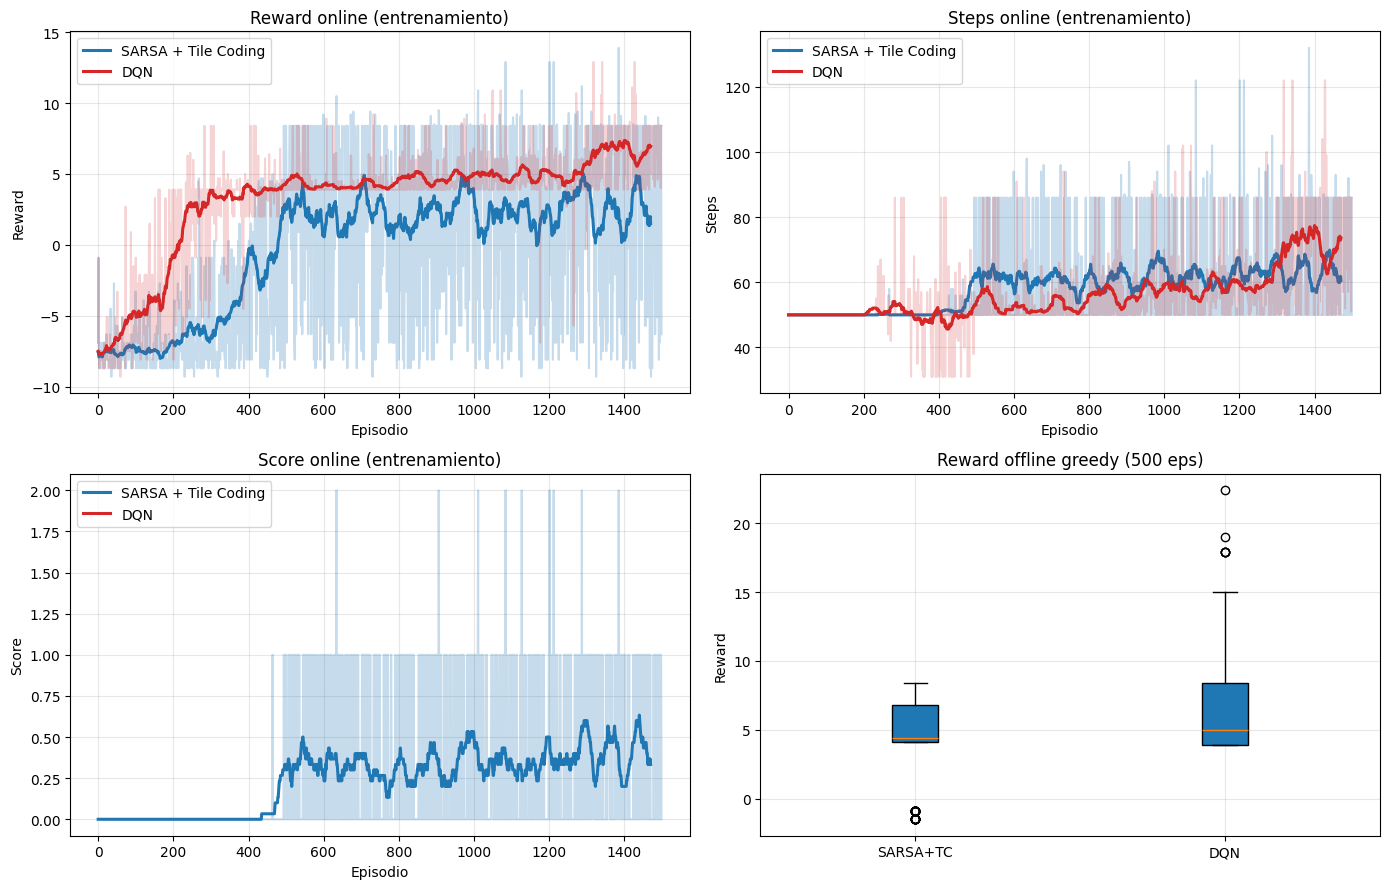


=== Resumen final: SARSA(TC) vs DQN ===
SARSA best cfg -> bins=6, alpha=0.01000
DQN best cfg -> lr=1e-03, buffer=30000
SARSA online reward (ult.100): 2.312 +- 5.992
DQN   online reward (ult.100): 6.660 +- 2.039
SARSA offline greedy reward:   4.933 +- 2.657
DQN   offline greedy reward:   6.372 +- 2.890
SARSA media score (ult.100):   0.390
DQN   media score (ult.100):   nan


c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# Comparación principal - visualización y resumen
def moving_avg(x, w=30):
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

fig, ax = plt.subplots(2, 2, figsize=(14, 9))

# Reward online
ax[0, 0].plot(r_sarsa, alpha=0.25, color="#1f77b4")
ax[0, 0].plot(moving_avg(r_sarsa, 30), linewidth=2.2, color="#1f77b4", label="SARSA + Tile Coding")
ax[0, 0].plot(r_dqn, alpha=0.20, color="#d62728")
ax[0, 0].plot(moving_avg(r_dqn, 30), linewidth=2.2, color="#d62728", label="DQN")
ax[0, 0].set_title("Reward online (entrenamiento)")
ax[0, 0].set_xlabel("Episodio")
ax[0, 0].set_ylabel("Reward")
ax[0, 0].grid(alpha=0.3)
ax[0, 0].legend()

# Steps online
ax[0, 1].plot(st_sarsa, alpha=0.25, color="#1f77b4")
ax[0, 1].plot(moving_avg(st_sarsa, 30), linewidth=2.2, color="#1f77b4", label="SARSA + Tile Coding")
ax[0, 1].plot(st_dqn, alpha=0.20, color="#d62728")
ax[0, 1].plot(moving_avg(st_dqn, 30), linewidth=2.2, color="#d62728", label="DQN")
ax[0, 1].set_title("Steps online (entrenamiento)")
ax[0, 1].set_xlabel("Episodio")
ax[0, 1].set_ylabel("Steps")
ax[0, 1].grid(alpha=0.3)
ax[0, 1].legend()

# Score online
ax[1, 0].plot(sc_sarsa, alpha=0.25, color="#1f77b4")
ax[1, 0].plot(moving_avg(sc_sarsa, 30), linewidth=2.2, color="#1f77b4", label="SARSA + Tile Coding")
ax[1, 0].plot(sc_dqn, alpha=0.20, color="#d62728")
ax[1, 0].plot(moving_avg(sc_dqn, 30), linewidth=2.2, color="#d62728", label="DQN")
ax[1, 0].set_title("Score online (entrenamiento)")
ax[1, 0].set_xlabel("Episodio")
ax[1, 0].set_ylabel("Score")
ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend()

# Offline greedy
ax[1, 1].boxplot([offline_sarsa, offline_dqn], labels=["SARSA+TC", "DQN"], patch_artist=True)
ax[1, 1].set_title(f"Reward offline greedy ({N_EVAL_EPISODES} eps)")
ax[1, 1].set_ylabel("Reward")
ax[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Resumen final: SARSA(TC) vs DQN ===")
print(f"SARSA best cfg -> bins={6}, alpha={0.01:.5f}")
print(f"DQN best cfg -> lr={best_dqn_cfg['learning_rate']:.0e}, buffer={best_dqn_cfg['buffer_capacity']}")
print(f"SARSA online reward (ult.100): {np.mean(r_sarsa[-100:]):.3f} +- {np.std(r_sarsa[-100:]):.3f}")
print(f"DQN   online reward (ult.100): {np.mean(r_dqn[-100:]):.3f} +- {np.std(r_dqn[-100:]):.3f}")
print(f"SARSA offline greedy reward:   {np.mean(offline_sarsa):.3f} +- {np.std(offline_sarsa):.3f}")
print(f"DQN   offline greedy reward:   {np.mean(offline_dqn):.3f} +- {np.std(offline_dqn):.3f}")
print(f"SARSA media score (ult.100):   {np.mean(sc_sarsa[-100:]):.3f}")
print(f"DQN   media score (ult.100):   {np.mean(sc_dqn[-100:]):.3f}")

Podemos ver que el algoritmo DQN consigue mejores resultados y converge antes a recompensas positivas, consiguiendo una recompensa máxima entorno a 25, mientras que SARSA converge más tarde y muestra un desempeño ligeramente peor con una recompensa máxima inferior a 10. Esto puede ser debido al replay buffer que permite a la DQN a aprender de más experiencias en cada iteración.

## 3.3. Sensibilidad a la Arquitectura de la Red (DQN)

Se estudia el impacto de la arquitectura de DQN variando:
- `hidden_dim` (ancho de capas ocultas)
- `num_layers` (profundidad)

Para aislar este efecto, se fijan `learning_rate` y `buffer_capacity` en los mejores valores encontrados previamente.

DQN n=1: 100%|██████████| 1500/1500 [00:49<00:00, 30.25ep/s]


Tabla de arquitecturas DQN (ordenada por reward_last50):


,hidden_dim,num_layers,reward_early,reward_last50,steps_last50
0,128,3,3.481267,6.870,75.44
1,64,3,3.160333,6.740,72.10
2,128,4,3.112933,5.002,58.86
3,32,1,2.263733,3.976,50.76
4,64,1,2.590733,3.954,50.54



Mejor arquitectura DQN: hidden_dim=128, num_layers=3


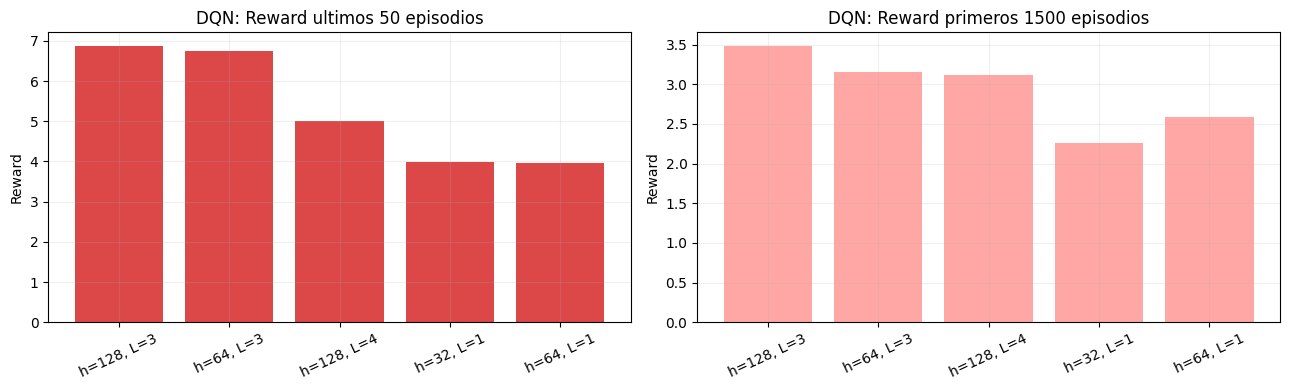

In [ ]:
# =========================
# Barrido de arquitectura DQN
# =========================

import pandas as pd

best_dqn_cfg = globals().get("best_dqn_cfg", {"learning_rate": 1e-4, "buffer_capacity": 50000})

architecture_grid = [
    {"hidden_dim": 32,  "num_layers": 1},
    {"hidden_dim": 64,  "num_layers": 1},
    {"hidden_dim": 64,  "num_layers": 3},
    {"hidden_dim": 128, "num_layers": 3},
    {"hidden_dim": 128, "num_layers": 4},
]

N_ARCH_EPISODES = N_EPISODES
N_ARCH_EARLY = N_ARCH_EPISODES
arch_results = []

for cfg in architecture_grid:
    env_arch = make_option2_env(SEED)
    agent_arch = DQNAgent(
        env_arch,
        hidden_dim=cfg["hidden_dim"],
        num_layers=cfg["num_layers"],
        learning_rate=best_dqn_cfg["learning_rate"],
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995,
        buffer_capacity=best_dqn_cfg["buffer_capacity"],
        batch_size=32,
        n_steps=1,
        learning_starts=1000,
        train_freq=10,
        target_update_freq=500,
        tau=1.0,
        double_dqn=True,
        seed=SEED,
        device=device,
    )

    r_arch, st_arch, _ = agent_arch.train(episodes=N_ARCH_EPISODES, max_steps=2000)
    r_arch = np.asarray(r_arch, dtype=float)
    st_arch = np.asarray(st_arch, dtype=float)

    arch_results.append({
        "hidden_dim": cfg["hidden_dim"],
        "num_layers": cfg["num_layers"],
        "reward_early": float(np.mean(r_arch[:N_ARCH_EARLY])),
        "reward_last50": float(np.mean(r_arch[-50:])),
        "steps_last50": float(np.mean(st_arch[-50:])),
    })

arch_df = pd.DataFrame(arch_results).sort_values(by=["reward_last50", "reward_early"], ascending=False).reset_index(drop=True)
best_arch = arch_df.iloc[0]

print("\nTabla de arquitecturas DQN (ordenada por reward_last50):")
display(arch_df)
print(f"\nMejor arquitectura DQN: hidden_dim={int(best_arch['hidden_dim'])}, num_layers={int(best_arch['num_layers'])}")

labels = [f"h={int(r['hidden_dim'])}, L={int(r['num_layers'])}" for _, r in arch_df.iterrows()]

Podemos ver que la mejor configuración es 128x3 consiguiendo una recompensa promedio en las últimas 50 iteraciones de 6.87, la arquitectura con 64 nodos y 3 capas tambien consigue un resultado muy positivo, por otro lado las arquitecturas con peores resultados son las que tienen solo una capa.

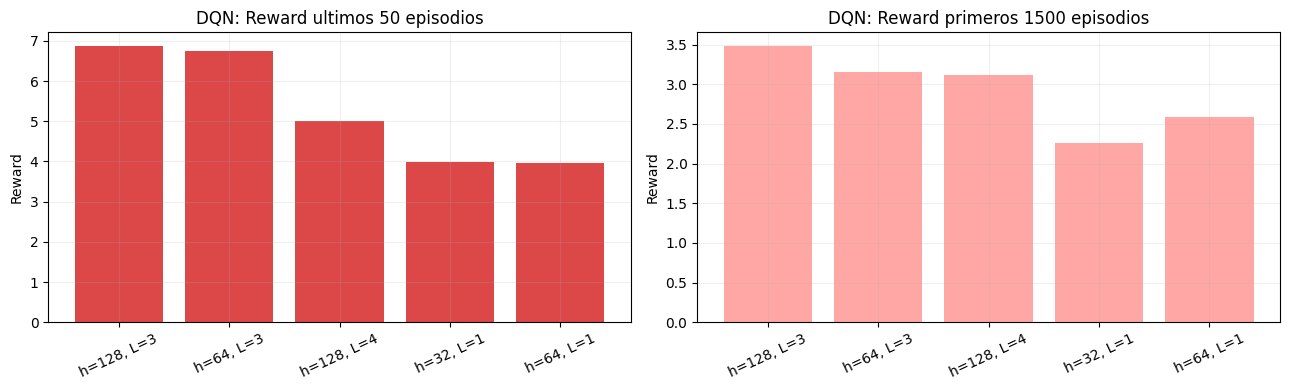

In [ ]:

# Grafica de barras: rendimiento por arquitectura
labels = [f"h={int(r['hidden_dim'])}, L={int(r['num_layers'])}" for _, r in arch_df.iterrows()]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(labels, arch_df["reward_last50"], color="#d62728", alpha=0.85)
ax[0].set_title("DQN: Reward ultimos 50 episodios")
ax[0].set_ylabel("Reward")
ax[0].tick_params(axis='x', rotation=25)
ax[0].grid(alpha=0.2)

ax[1].bar(labels, arch_df["reward_early"], color="#ff9896", alpha=0.85)
ax[1].set_title(f"DQN: Reward primeros {N_ARCH_EARLY} episodios")
ax[1].set_ylabel("Reward")
ax[1].tick_params(axis='x', rotation=25)
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 3.4. Frame Stacking
En este apartado vamos a realizar un experimento utilizando un wrapper que crea una cola de los k últimos estados y utiliza esto para entrenar y evaluar los algoritmos

In [ ]:
from src.agents.deep_q_learning import DQNAgent
from src.agents.SARSA_semi_grad import SARSASemiGradAgent
from gymnasium.wrappers import FrameStackObservation

# Usar las mejores configuraciones encontradas anteriormente o valores por defecto si no se han definido
best_sarsa_cfg = globals().get("best_sarsa_cfg", { "bins": 8})
best_dqn_cfg = globals().get("best_dqn_cfg", {"learning_rate": 1e-4, "buffer_capacity": 50000})

print("Configuración usada en Frame Stacking:")
print(f"SARSA -> alpha={0.01}, bins={6}")
print(f"DQN   -> lr={best_dqn_cfg['learning_rate']}, buffer={best_dqn_cfg['buffer_capacity']}")

def env_factory_stack(seed: int = SEED, k: int = 1):
    env = gym.make('FlappyBird-v0', use_lidar=False)
    env = FrameStackObservation(env, k)
    env.reset(seed=seed)
    return env

# Configuración de experimentos
stack_configs = [
    ("1 frame",  env_factory_stack(SEED, 1), 1),
    ("3 frames", env_factory_stack(SEED, 3), 3),
    ("6 frames", env_factory_stack(SEED, 6), 6)
]

results_dqn_stack = {}
results_sarsa_sg_stack = {}

for name, env, num_frames in stack_configs:
    print(f"\n{'='*60}")
    print(f"Entrenando DQN con {name}...")
    print(f"{'='*60}")

    agent_dqn = DQNAgent(
        env,
        hidden_dim=128,
        num_layers=3,
        learning_rate=best_dqn_cfg["learning_rate"],
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        buffer_capacity=best_dqn_cfg["buffer_capacity"],
        batch_size=32,
        n_steps=1,
        learning_starts=1000,
        train_freq=10,
        target_update_freq=500,
        tau=1.0,
        double_dqn=True,
        seed=SEED,
        device=device,
    )
    train_rewards_dqn, train_steps_dqn, train_score_dqn = agent_dqn.train(episodes=N_EPISODES, max_steps=2000)

    results_dqn_stack[num_frames] = {
        "name": name,
        "rewards": train_rewards_dqn,
        "steps": train_steps_dqn,
        "scores": train_score_dqn,
        "network": agent_dqn.q_net,
    }

    print(f"Entrenando SARSA semi-grad con {name}...")
    env_sg = env_factory_stack(SEED, num_frames)
    tc_sg = SimpleTileCoder(
        low=env_sg.observation_space.low,
        high=env_sg.observation_space.high,
        n_tilings=n_tilings,
        bins=6,
        iht_size=4096,
        seed=SEED,
    )

    agent_sg = SARSASemiGradAgent(
        env_sg,
        alpha=0.01,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        n_steps=1,
        feature_encoder=tc_sg.encode,
        seed=SEED,
    )
    train_rewards_sg, train_steps_sg, train_score_sg = agent_sg.train(episodes=N_EPISODES, max_steps=2000)

    results_sarsa_sg_stack[num_frames] = {
        "name": name,
        "rewards": train_rewards_sg,
        "steps": train_steps_sg,
        "scores": train_score_sg,
        "weights": agent_sg.weights,
    }

print("\n" + "="*60)
print("Entrenamiento completado para todos los frame stacks")
print("="*60)


Configuración usada en Frame Stacking:
SARSA -> alpha=0.01, bins=6
DQN   -> lr=0.001, buffer=30000

Entrenando DQN con 1 frame...


DQN n=1: 100%|██████████| 1500/1500 [00:39<00:00, 37.73ep/s]


Entrenando SARSA semi-grad con 1 frame...


SARSA semi-grad n=1: 100%|██████████| 1500/1500 [02:24<00:00, 10.39ep/s]



Entrenando DQN con 3 frames...


...


Entrenando DQN con 6 frames...


DQN n=1: 100%|██████████| 1500/1500 [00:45<00:00, 32.74ep/s]


Entrenando SARSA semi-grad con 6 frames...


SARSA semi-grad n=1: 100%|██████████| 1500/1500 [10:37<00:00,  2.35ep/s]


Entrenamiento completado para todos los frame stacks



RESUMEN FINAL - Comparativa por Frame Stacking
N frames        | Puntuación (últimos 100)  | Pasos (últimos 100)      
--------------------------------------------------------------------------------
 DQN     : 1 frame         |   7.27 ±  3.03         |  76.09 ± 24.17
 SARSA SG: 1 frame         |   6.82 ±  3.74         |  79.06 ± 13.85
 DQN     : 3 frames        |   3.45 ±  3.23         |  50.55 ± 15.39
 SARSA SG: 3 frames        |  -8.68 ±  0.10         |  50.00 ±  0.00
 DQN     : 6 frames        |   6.87 ±  4.34         |  73.09 ± 34.79
 SARSA SG: 6 frames        |  -0.01 ±  1.51         |  50.00 ±  0.00


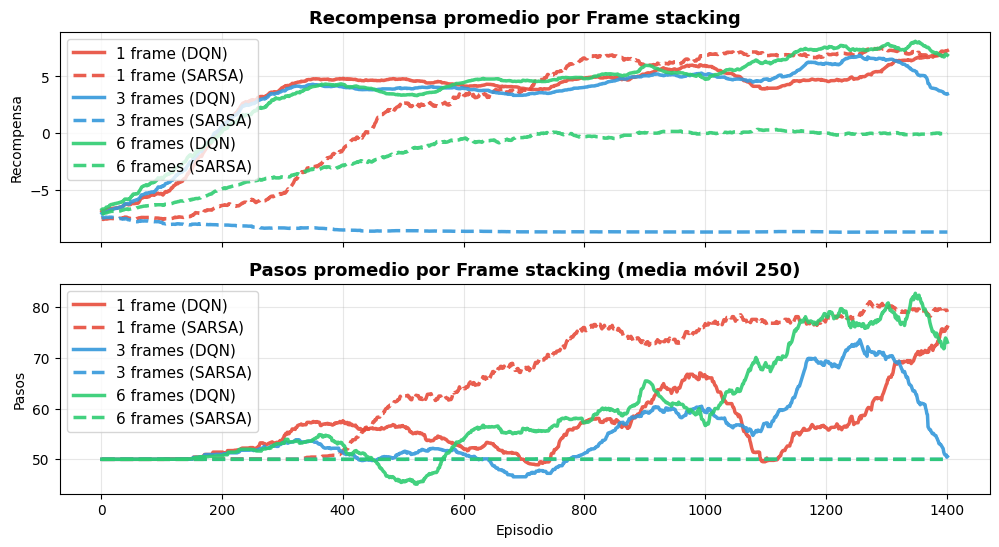

In [ ]:
# ============ GRÁFICAS: Comparativa por Densidad de LiDAR (DQN) ============
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

colors_stacks = {1: "#e74c3c", 3: "#3498db", 6: "#2ecc71"}

# Recompensas suavizadas
for num_stacks in [1, 3, 6]:
    smooth_rewards_dqn = moving_average(results_dqn_stack[num_stacks]["rewards"], N_SMOOTH)
    smooth_rewards_sarsa = moving_average(results_sarsa_sg_stack[num_stacks]["rewards"], N_SMOOTH)
    ax[0].plot(
        np.arange(1, len(smooth_rewards_dqn) + 1),
        smooth_rewards_dqn,
        linewidth=2.5,
        color=colors_stacks[num_stacks],
        label=results_dqn_stack[num_stacks]["name"]+ " (DQN)",
        alpha=0.9
    )
    ax[0].plot(
        np.arange(1, len(smooth_rewards_sarsa) + 1),
        smooth_rewards_sarsa,
        linewidth=2.5,
        linestyle="--",
        color=colors_stacks[num_stacks],
        label=results_sarsa_sg_stack[num_stacks]["name"]+ " (SARSA)",
        alpha=0.9
    )

ax[0].set_title("Recompensa promedio por Frame stacking", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Recompensa")
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=11)

# Steps suavizados
for num_stacks in [1, 3, 6]:
    smooth_steps_dqn = moving_average(results_dqn_stack[num_stacks]["steps"], N_SMOOTH)
    smooth_steps_sarsa = moving_average(results_sarsa_sg_stack[num_stacks]["steps"], N_SMOOTH)

    ax[1].plot(
        np.arange(1, len(smooth_steps_dqn) + 1),
        smooth_steps_dqn,
        linewidth=2.5,
        color=colors_stacks[num_stacks],
        label=results_dqn_stack[num_stacks]["name"]+ " (DQN)",
        alpha=0.9
    )
    ax[1].plot(
        np.arange(1, len(smooth_steps_sarsa) + 1),
        smooth_steps_sarsa,
        linewidth=2.5,
        color=colors_stacks[num_stacks],
        linestyle="--",
        label=results_sarsa_sg_stack[num_stacks]["name"]+ " (SARSA)",
        alpha=0.9
    )

ax[1].set_title("Pasos promedio por Frame stacking (media móvil 250)", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Episodio")
ax[1].set_ylabel("Pasos")
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=11)


# ============ RESUMEN NUMÉRICO FINAL ============
print("\n" + "="*80)
print("RESUMEN FINAL - Comparativa por Frame Stacking")
print("="*80)
print(f"{'N frames':<15} | {'Puntuación (últimos 100)':<25} | {'Pasos (últimos 100)':<25}")
print("-"*80)

for num_stacks in [1, 3, 6]:
    r_dqn = results_dqn_stack[num_stacks]["rewards"]
    s_dqn = results_dqn_stack[num_stacks]["steps"]
    name_dqn = results_dqn_stack[num_stacks]["name"]

    r_sarsa = results_sarsa_sg_stack[num_stacks]["rewards"]
    s_sarsa = results_sarsa_sg_stack[num_stacks]["steps"]
    name_sarsa = results_sarsa_sg_stack[num_stacks]["name"]


    print(f" DQN     : {name_dqn:<15} | {np.mean(r_dqn[-100:]):6.2f} ± {np.std(r_dqn[-100:]):5.2f}         | {np.mean(s_dqn[-100:]):6.2f} ± {np.std(s_dqn[-100:]):5.2f}")
    print(f" SARSA SG: {name_sarsa:<15} | {np.mean(r_sarsa[-100:]):6.2f} ± {np.std(r_sarsa[-100:]):5.2f}         | {np.mean(s_sarsa[-100:]):6.2f} ± {np.std(s_sarsa[-100:]):5.2f}")

print("="*80)

Podemos ver que DQN consigue resultados aceptables con todas las configuraciones de k, mientras que SARSA solo destaca con 1 frame y empeora de forma lineal al incrementar los frames, tambien es destacable que DQN converge antes que SARSA en todas las configuraciones.

## 3.5. n-steps

En este experimento evaluamos ambos algoritmos variando el horizonte de retorno (n)-step para analizar cómo afecta al aprendizaje y al rendimiento final.

In [ ]:
from src.agents.deep_q_learning import DQNAgent
from src.agents.SARSA_semi_grad import SARSASemiGradAgent

# Usar las mejores configuraciones encontradas en 3.3 y 3.4
best_sarsa_cfg = globals().get("best_sarsa_cfg", {"alpha": 0.01, "bins": 8})
best_dqn_cfg = globals().get("best_dqn_cfg", {"learning_rate": 1e-4, "buffer_capacity": 50000})

print("Configuración usada en experimento n-steps:")
print(f"SARSA -> alpha={0.01}, bins={6}")
print(f"DQN   -> lr={best_dqn_cfg['learning_rate']}, buffer={best_dqn_cfg['buffer_capacity']}")

n_steps_list = [1, 5, 10]
results_dqn_stack = {}
results_sarsa_sg_stack = {}

for n_steps in n_steps_list:
    print(f"\n{'='*60}")
    print(f"Entrenando DQN con {n_steps} pasos...")
    print(f"{'='*60}")

    env_dqn_ns = env_factory_stack(SEED, 6)
    agent_dqn = DQNAgent(
        env_dqn_ns,
        hidden_dim=64,
        num_layers=3,
        learning_rate=best_dqn_cfg["learning_rate"],
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        buffer_capacity=best_dqn_cfg["buffer_capacity"],
        batch_size=32,
        n_steps=n_steps,
        learning_starts=1000,
        train_freq=10,
        target_update_freq=500,
        tau=1.0,
        double_dqn=True,
        seed=SEED,
        device=device,
    )
    train_rewards_dqn, train_steps_dqn, train_score_dqn = agent_dqn.train(episodes=N_EPISODES, max_steps=2000)

    results_dqn_stack[n_steps] = {
        "name": f"DQN {n_steps} pasos",
        "rewards": train_rewards_dqn,
        "steps": train_steps_dqn,
        "scores": train_score_dqn,
        "network": agent_dqn.q_net,
    }

    print(f"Entrenando SARSA semi-grad con {n_steps} pasos...")
    env_sg_ns = make_option2_env(SEED)
    tc_sg_ns = SimpleTileCoder(
        low=env_sg_ns.observation_space.low,
        high=env_sg_ns.observation_space.high,
        n_tilings=n_tilings,
        bins=6,
        iht_size=4096,
        seed=SEED,
    )
    agent_sg = SARSASemiGradAgent(
        env_sg_ns,
        alpha=0.01,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        n_steps=n_steps,
        feature_encoder=tc_sg_ns.encode,
        seed=SEED,
    )
    train_rewards_sg, train_steps_sg, train_score_sg = agent_sg.train(episodes=N_EPISODES, max_steps=2000)

    results_sarsa_sg_stack[n_steps] = {
        "name": f"SARSA Semi-Grad {n_steps} pasos",
        "rewards": train_rewards_sg,
        "steps": train_steps_sg,
        "scores": train_score_sg,
        "weights": agent_sg.weights,
    }

print("\n" + "="*60)
print("Entrenamiento completado para n_steps = [1, 5, 10]")
print("="*60)


Configuración usada en experimento n-steps:
SARSA -> alpha=0.01, bins=6
DQN   -> lr=0.001, buffer=30000

Entrenando DQN con 1 pasos...


DQN n=1: 100%|██████████| 1500/1500 [00:40<00:00, 37.27ep/s]


Entrenando SARSA semi-grad con 1 pasos...


SARSA semi-grad n=1: 100%|██████████| 1500/1500 [02:31<00:00,  9.87ep/s]



Entrenando DQN con 5 pasos...


...


Entrenando DQN con 10 pasos...


DQN n=10: 100%|██████████| 1500/1500 [00:35<00:00, 41.92ep/s]


Entrenando SARSA semi-grad con 10 pasos...


SARSA semi-grad n=10: 100%|██████████| 1500/1500 [01:59<00:00, 12.54ep/s]


Entrenamiento completado para n_steps = [1, 5, 10]


En la siguiente celda se muestran las gráficas del entrenamiento de n pasos

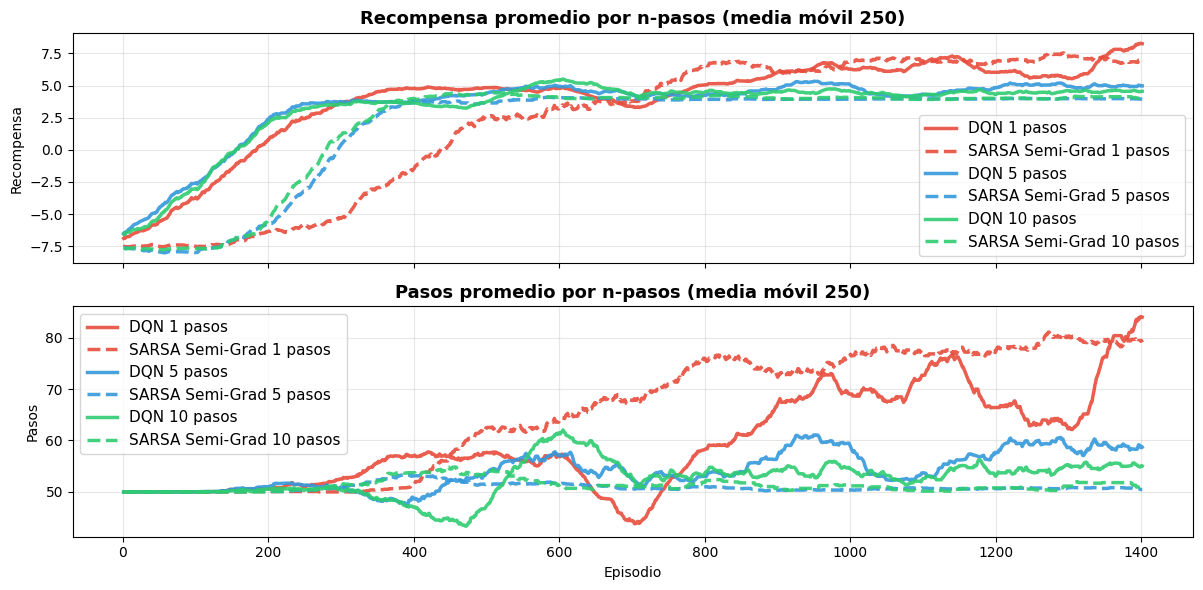


RESUMEN FINAL - Comparativa por n-pasos
N frames        | Puntuación (últimos 100)  | Pasos (últimos 100)      
--------------------------------------------------------------------------------
 DQN     : DQN 1 pasos     |   8.26 ±  2.89         |  83.98 ± 22.86 |    nan ±   nan
 SARSA SG: SARSA Semi-Grad 1 pasos |   6.82 ±  3.74         |  79.06 ± 13.85 |   0.83 ±  0.40
 DQN     : DQN 5 pasos     |   4.98 ±  1.75         |  58.70 ± 13.93 |    nan ±   nan
 SARSA SG: SARSA Semi-Grad 5 pasos |   3.95 ±  0.18         |  50.47 ±  1.81 |   0.00 ±  0.00
 DQN     : DQN 10 pasos    |   4.56 ±  1.09         |  55.04 ±  8.07 |    nan ±   nan
 SARSA SG: SARSA Semi-Grad 10 pasos |   4.07 ±  0.91         |  51.31 ±  6.96 |   0.05 ±  0.26


c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\AntonioLuisTorres\.conda\envs\eml-flappy\Lib\site-packages\numpy\_core\_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [ ]:
# ============ GRÁFICAS: Comparativa por Densidad de LiDAR (DQN) ============
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

colors_stacks = {1: "#e74c3c", 5: "#3498db", 10: "#2ecc71"}

# Recompensas suavizadas
for num_stacks in [1, 5, 10]:
    smooth_rewards_dqn = moving_average(results_dqn_stack[num_stacks]["rewards"], N_SMOOTH)
    smooth_rewards_sarsa = moving_average(results_sarsa_sg_stack[num_stacks]["rewards"], N_SMOOTH)
    ax[0].plot(
        np.arange(1, len(smooth_rewards_dqn) + 1),
        smooth_rewards_dqn,
        linewidth=2.5,
        color=colors_stacks[num_stacks],
        label=results_dqn_stack[num_stacks]["name"],
        alpha=0.9
    )
    ax[0].plot(
        np.arange(1, len(smooth_rewards_sarsa) + 1),
        smooth_rewards_sarsa,
        linewidth=2.5,
        linestyle="--",
        color=colors_stacks[num_stacks],
        label=results_sarsa_sg_stack[num_stacks]["name"],
        alpha=0.9
    )

ax[0].set_title("Recompensa promedio por n-pasos (media móvil 250)", fontsize=13, fontweight="bold")
ax[0].set_ylabel("Recompensa")
ax[0].grid(alpha=0.3)
ax[0].legend(fontsize=11)

# Steps suavizados
for num_stacks in [1, 5, 10]:
    smooth_steps_dqn = moving_average(results_dqn_stack[num_stacks]["steps"], N_SMOOTH)
    smooth_steps_sarsa = moving_average(results_sarsa_sg_stack[num_stacks]["steps"], N_SMOOTH)

    ax[1].plot(
        np.arange(1, len(smooth_steps_dqn) + 1),
        smooth_steps_dqn,
        linewidth=2.5,
        color=colors_stacks[num_stacks],
        label=results_dqn_stack[num_stacks]["name"],
        alpha=0.9
    )
    ax[1].plot(
        np.arange(1, len(smooth_steps_sarsa) + 1),
        smooth_steps_sarsa,
        linewidth=2.5,
        color=colors_stacks[num_stacks],
        linestyle="--",
        label=results_sarsa_sg_stack[num_stacks]["name"],
        alpha=0.9
    )

ax[1].set_title("Pasos promedio por n-pasos (media móvil 250)", fontsize=13, fontweight="bold")
ax[1].set_xlabel("Episodio")
ax[1].set_ylabel("Pasos")
ax[1].grid(alpha=0.3)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# ============ RESUMEN NUMÉRICO FINAL ============
print("\n" + "="*80)
print("RESUMEN FINAL - Comparativa por n-pasos")
print("="*80)
print(f"{'N frames':<15} | {'Puntuación (últimos 100)':<25} | {'Pasos (últimos 100)':<25}")
print("-"*80)

for num_stacks in [1, 5, 10]:
    r_dqn = results_dqn_stack[num_stacks]["rewards"]
    s_dqn = results_dqn_stack[num_stacks]["steps"]
    name_dqn = results_dqn_stack[num_stacks]["name"]

    r_sarsa = results_sarsa_sg_stack[num_stacks]["rewards"]
    s_sarsa = results_sarsa_sg_stack[num_stacks]["steps"]
    name_sarsa = results_sarsa_sg_stack[num_stacks]["name"]


    print(f" DQN     : {name_dqn:<15} | {np.mean(r_dqn[-100:]):6.2f} ± {np.std(r_dqn[-100:]):5.2f}         | {np.mean(s_dqn[-100:]):6.2f} ± {np.std(s_dqn[-100:]):5.2f} | {np.mean(results_dqn_stack[num_stacks]['scores'][-100:]):6.2f} ± {np.std(results_dqn_stack[num_stacks]['scores'][-100:]):5.2f}")
    print(f" SARSA SG: {name_sarsa:<15} | {np.mean(r_sarsa[-100:]):6.2f} ± {np.std(r_sarsa[-100:]):5.2f}         | {np.mean(s_sarsa[-100:]):6.2f} ± {np.std(s_sarsa[-100:]):5.2f} | {np.mean(results_sarsa_sg_stack[num_stacks]['scores'][-100:]):6.2f} ± {np.std(results_sarsa_sg_stack[num_stacks]['scores'][-100:]):5.2f}")

print("="*80)

Podemos ver como DQN converge antes, y aunque todos los resutlados son más o menos parecidos los mejores resultados se dan con 1 paso.

## 3.6. Generación de Video de los Mejores Modelos

En este apartado se generan videos de evaluación greedy para los mejores modelos guardados de:
- SARSA + Tile Coding
- DQN

Los videos se guardan en `Entornos_continuos/artifacts/videos/`.

In [ ]:
# =========================
# Videos de evaluación greedy: mejores modelos SARSA y DQN (sin moviepy)
# =========================

import os
import sys
import subprocess
import importlib.util
import gymnasium as gym

analysis_sarsa_agent, analysis_dqn_agent, _, _ = load_best_agents_for_analysis()

VIDEO_DIR = os.path.join("Entornos_continuos", "artifacts", "videos")
os.makedirs(VIDEO_DIR, exist_ok=True)


import imageio.v2 as imageio


def record_video_with_imageio(agent, env_id="FlappyBird-v0", env_kwargs=None, output_path=None, max_steps=2000, seed=SEED, fps=30):
    """
    Graba un episodio greedy capturando frames con imageio.

    """
    kwargs = dict(env_kwargs or {})
    env = gym.make(env_id, render_mode="rgb_array", **kwargs)

    if output_path is None:
        output_path = os.path.join(VIDEO_DIR, "agent_eval.mp4")

    old_eps = getattr(agent, "epsilon", None)
    if old_eps is not None:
        agent.epsilon = 0.0

    try:
        obs, _ = env.reset(seed=seed)
        frames = []

        # Primer frame
        frame = env.render()
        if frame is not None:
            frames.append(frame)

        done = False
        step = 0
        while step < max_steps and not done:
            action = agent.get_action(obs, evaluate=True)
            obs, _, terminated, truncated, _ = env.step(action)
            done = bool(terminated or truncated)

            frame = env.render()
            if frame is not None:
                frames.append(frame)
            step += 1

        imageio.mimsave(output_path, frames, fps=fps)
    finally:
        if old_eps is not None:
            agent.epsilon = old_eps
        env.close()

    return output_path


video_sarsa = record_video_with_imageio(
    analysis_sarsa_agent,
    env_id="FlappyBird-v0",
    env_kwargs={"use_lidar": False},
    output_path=os.path.join(VIDEO_DIR, "best_sarsa_tc.mp4"),
    max_steps=2000,
    seed=SEED,
    fps=30,
)

video_dqn = record_video_with_imageio(
    analysis_dqn_agent,
    env_id="FlappyBird-v0",
    env_kwargs={"use_lidar": False},
    output_path=os.path.join(VIDEO_DIR, "best_dqn.mp4"),
    max_steps=2000,
    seed=SEED + 1,
    fps=30,
)

print("Videos generados:")
print(f"- SARSA: {video_sarsa}")
print(f"- DQN:   {video_dqn}")

C:\Users\AntonioLuisTorres\AppData\Local\Temp\ipykernel_6800\3003694955.py:109: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  s_ckpt = torch.load(SARSA_CKPT_PATH, map_locati

Videos generados:
- SARSA: Entornos_continuos\artifacts\videos\best_sarsa_tc.mp4
- DQN:   Entornos_continuos\artifacts\videos\best_dqn.mp4


# Videos Generados

In [ ]:
from IPython.display import display, Video, Markdown

# Rutas de video ya generadas en celdas anteriores (con fallback)
video_sarsa_path = globals().get("video_sarsa", os.path.join("Entornos_continuos", "artifacts", "videos", "best_sarsa_tc.mp4"))
video_dqn_path = globals().get("video_dqn", os.path.join("Entornos_continuos", "artifacts", "videos", "best_dqn.mp4"))

for titulo, path in [("SARSA + Tile Coding", video_sarsa_path), ("DQN", video_dqn_path)]:
    if os.path.exists(path):
        display(Markdown(f"### {titulo}"))
        display(Video(path, embed=True, html_attributes="controls autoplay loop muted"))
    else:
        print(f"No se encontró el video: {path}")

### SARSA + Tile Coding

### DQN

# Uso de IA Generativa

Para desarrollar el notebook se han utilizado las recomendaciones de Visual Studio Code y Github Copilot. Tambien se ha utilizado para la generación de gráficas y su estilo el chat de Github copilot.